In [1]:
using ZetaReg

## running test 
include("./test/runtests.jl")


Initial Data from InsuranceData:
num_insurances (Z):
94, 342, 590, 433, 177, 59
6, 34, 66, 59, 30, 12
0, 5, 16, 11, 6, 8
0, 3, 8, 7, 2, 2
0, 0, 0, 3, 4, 2
0, 2, 3, 3, 0, 0
0, 0, 2, 2, 0, 0
0, 0, 1, 1, 1, 0
0, 0, 1, 0, 0, 0
0, 0, 0, 1, 0, 0
0, 0, 2, 0, 0, 0
0, 0, 0, 0, 0, 0
0, 0, 0, 1, 0, 0
0, 0, 0, 0, 0, 0
0, 0, 0, 0, 0, 0
0, 0, 0, 0, 0, 0
0, 0, 0, 0, 1, 0
0, 0, 0, 0, 0, 0

age (W):
20, 30, 40, 50, 60, 70

Comparison of Results:
Method           | β (first)   | θ (min)   | iters | log-likelihood (last)
QDE               | 4.3655     | 2.4156     | 5     | -1198.2801
ZetaMeanModel     | -1.1905    | 2.5885     | 9     | -1197.2282
ZetaMeanLogModel  | -1.9572    | 2.5514     | 8     | -1197.4561
Detailed Vectors (β and θ):
Index | QDE β      | ZetaMean β      | ZetaMeanLog β   || QDE θ      | ZetaMean θ      | ZetaMeanLog θ   
1     | 4.3655     | -1.1905         | -1.9572         || 3.8084     | 3.9200          | 3.8385         
2     | -0.0279    | 0.6953          | 0.4888          || 

Test.DefaultTestSet("ZetaReg Tests for CitiesData", Any[], 0, false, false, true, 1.737842214788384e9, 1.737842214813987e9, false, "/Users/caleblee/Codes/Julia/MyPack/ZetaReg/test/runtests.jl")

In [2]:
using ZetaReg, CSV, DataFrames, StatsBase, Plots, SpecialFunctions, Printf

# 读取 CSV 文件
df1 = CSV.read("src/datasets/census2000.csv", DataFrame)
df2 = CSV.read("src/datasets/census2010.csv", DataFrame)
df3 = CSV.read("src/datasets/census2020.csv", DataFrame)

# 假设 df1 是您的数据框
# result = subset(df1, df1.SUMLEV == 50)

# result = subset(df1, df1.SUMLEV .== 50)  # 注意使用了 .== 进行逐元素比较

data1 = df1
data1.CENSUS2000POP = [tryparse(Int, s) for s in data1.CENSUS2000POP]
data1 = filter(row -> row.SUMLEV .== 50 && row.CENSUS2000POP !== nothing, data1)
data1 = select(data1, [:STATE, :CENSUS2000POP])

data2 = df2
data2.CENSUS2010POP = [tryparse(Float64, String(x)) for x in data2.CENSUS2010POP]
data2 = filter(row -> row.SUMLEV .== 50 && row.CENSUS2010POP !== nothing, data2)
data2 = select(data2, [:STATE, :CENSUS2010POP])

data3 = df3
# data3.ESTIMATESBASE2020 = [tryparse(Float64, Int(x)) for x in data3.ESTIMATESBASE2020]
data3 = filter(row -> row.SUMLEV .== 50 , data3)
data3 = select(data3, [:STATE, :ESTIMATESBASE2020])


# 使用 data2 作为示例数据
data = data2

# 使用 cut 函数划分区间
size1 = 4e4
data.CENSUS2010POP = ceil.(data[:,2]./size1)

# 获取所有唯一的分类标签
categories = unique(data.STATE)
maxCens = maximum(data[:,2])
W = zeros(Float64, length(categories), length(categories))
Z = zeros(Float64, Int(maxCens), length(categories))

cat0 = 0

for cat in categories
    cat0 = cat0 + 1
    W[cat0, cat0] = 1.0
    yTra = filter(row -> row.STATE .== cat , data)
    yTra = yTra[:,2]
    
    for i in yTra
        Z[Int(i),Int(cat0)] = Z[Int(i),Int(cat0)] + 1
    end
    
end


Fitting 2010 Census Frequency Data with the Zeta Distribution:


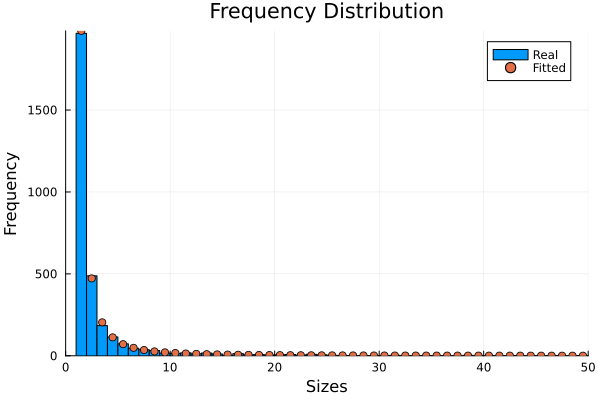

In [3]:

# 打印 InsuranceData 数据
println("Fitting 2010 Census Frequency Data with the Zeta Distribution:")
println("==============================================")

yy = data[:,2]
xx = range(1,50,50)
# plot_frequency(yy)
theta1 = Rootθ(mean(log.(yy)))
yy1 = (xx.^(-theta1))./zeta(theta1) * length(yy)

# 绘制图形
p = plot()


# 绘制频率分布的直方图
histogram!(p, yy, bins=Int(maximum(yy)), xlim=(0, 50), label = "Real" , xlabel="Sizes", ylabel="Frequency", title="Frequency Distribution")

# Shift xx 数据并添加拟合曲线
xx_shifted = xx .+ 0.5
plot!(p, xx_shifted, yy1, label = "Fitted", seriestype=:scatter)

# 显示图形
display(p)

In [4]:

println("==============================================\n")
# 假设 Z 和 W 是已定义的矩阵
(rho1, θ1, iters1, loglikelihoods1) = QDE(Z, W)
(rho2, θ2, iters2, loglikelihoods2) = ZetaMeanModel(Z, W)
(rho3, θ3, iters3, loglikelihoods3) = ZetaMeanLogModel(Z, W)


# 打印结果
println("Comparison of Results:")
println("====================================================================")
println("Method           | β (first)   | θ (min)   | iters | log-likelihood (last)")
println("====================================================================")
@printf("%-17s | %-10.4f | %-10.4f | %-5d | %-10.4f\n", "QDE", rho1[1], minimum(θ1), iters1, loglikelihoods1[end])
@printf("%-17s | %-10.4f | %-10.4f | %-5d | %-10.4f\n", "ZetaMeanModel", rho2[1], minimum(θ2), iters2, loglikelihoods2[end])
@printf("%-17s | %-10.4f | %-10.4f | %-5d | %-10.4f\n", "ZetaMeanLogModel", rho3[1], minimum(θ3), iters3, loglikelihoods3[end])
println("====================================================================")

# 打印表头
println("Detailed Vectors (β and θ):")
println("===============================================================================================================")
println("Index | QDE β      | ZetaMean β      | ZetaMeanLog β   || QDE θ      | ZetaMean θ      | ZetaMeanLog θ   ")
println("===============================================================================================================")

# 获取最大长度，确保遍历所有向量
max_len = maximum([length(rho1), length(rho2), length(rho3), length(θ1), length(θ2), length(θ3)])

# 按行打印
for i in 1:max_len
    β_qde = i <= length(rho1) ? @sprintf("%-10.4f", rho1[i]) : " " * " "
    β_zeta_mean = i <= length(rho2) ? @sprintf("%-15.4f", rho2[i]) : " " * " "
    β_zeta_log = i <= length(rho3) ? @sprintf("%-15.4f", rho3[i]) : " " * " "
    θ_qde = i <= length(θ1) ? @sprintf("%-10.4f", θ1[i]) : " " * " "
    θ_zeta_mean = i <= length(θ2) ? @sprintf("%-15.4f", θ2[i]) : " " * " "
    θ_zeta_log = i <= length(θ3) ? @sprintf("%-15.4f", θ3[i]) : " " * " "

    println(@sprintf("%-5d | %-10s | %-15s | %-15s || %-10s | %-15s | %-15s", 
                     i, β_qde, β_zeta_mean, β_zeta_log, θ_qde, θ_zeta_mean, θ_zeta_log))
end

println("===============================================================================================================")



There exists at least a non-real or NaN value. Stopping execution.
There exists at least a non-real or NaN value. Stopping execution.
Comparison of Results:
Method           | β (first)   | θ (min)   | iters | log-likelihood (last)
QDE               | 1.9975     | -0.2042    | 969   | NaN       
ZetaMeanModel     | 6.0177     | 2.0000     | 9     | -4607.7309
ZetaMeanLogModel  | -0.6796    | 1.3033     | 8     | -4495.2865
Detailed Vectors (β and θ):
Index | QDE β      | ZetaMean β      | ZetaMeanLog β   || QDE θ      | ZetaMean θ      | ZetaMeanLog θ   
1     | 1.9975     | 6.0177          | -0.6796         || 1.7879     | 2.0835          | 2.0490         
2     | -0.2096    | 0.2226          | 0.4259          || 3.7394     | 2.9295          | 2.9298         
3     | 1.7419     | -0.1742         | 0.2730          || 0.4713     | 2.0000          | 1.5245         
4     | -1.5262    | 2.0694          | 0.5638          || 2.5275     | 2.5969          | 2.5969         
5     | 0.5300    